In [7]:
import os
import numpy as np
import astropy.constants as c

# Note for grid design from K.O.
$[M/H]   = 0, 0.5, 1.0, 1.5, 2.0 $

Semi-major axis = $1170\times 10^{-x/2}$ AU (for Sun, x=6,7,8,9)

$T_{\rm int} = 24\times 10^{(y-1)/5} (y=1,2,...,11)$

$g       = 0.01\times10^{z} {\rm m/s^2}$ (z=1,2,3,4,5)

## The file name follows the format of "PT_Z($10^{[M/H]}$)_Teq($x$)_Tin($y$)_g($z00$).dat"
Example) "PT_Z10_Teq10_Tin011_g100.dat" $\rightarrow$ x=10, y=11, z=1

$\rightarrow$[M/H] = 1.0, Semi-major axis = $1170*10^{-10/2}=0.0117$ AU, Tint = $24\times{10^{10/5}}=2400$ K, g= 0.01$\times10^{1}$  m/s^2 = 0.1 m/s^2

## Make sure if all grids are present

In [8]:
# ---- Find missing grid ---
Zlist = ["1","3","10","31","100"]
#Zlist = ["100"]

n = 0
n_err = 0
for i in range(len(Zlist)):
    for Teq in range(6,10,1):
        for Tint in range(1,12,1):
            for grav in range(1,6,1):
                n = n+1
                fname = "PT_Z"+Zlist[i]+"_Teq"+str(Teq).zfill(2)+"_Tin"+str(Tint).zfill(3)+"_g"+str(grav*100)+".dat"                
                if not( os.path.exists(fname) ):
                    n_err = n_err+1
                    print(fname+' is not present')
                    
print('Total grid number would be '+str(n)+', Failed grids are '+str(n_err) )

PT_Z10_Teq09_Tin011_g100.dat is not present
PT_Z31_Teq06_Tin011_g100.dat is not present
PT_Z31_Teq07_Tin011_g100.dat is not present
PT_Z31_Teq08_Tin011_g100.dat is not present
PT_Z31_Teq09_Tin011_g100.dat is not present
Total grid number would be 1100, Failed grids are 5


# Plot TP grid for a certain metallicity

(100000.0, 1e-06)

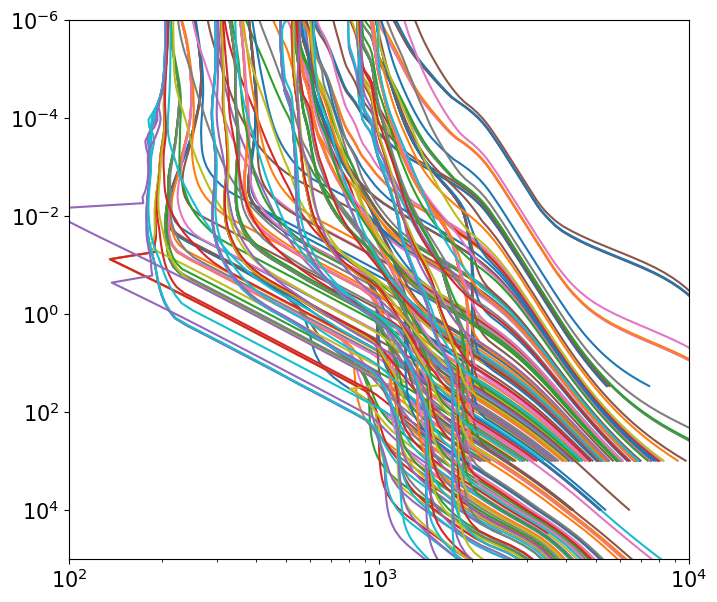

In [9]:
from matplotlib import pyplot as plt
plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = 8,7

# ---- Find missing grid ---
#Zlist = ["1","3","10","31","100"]
Zlist = ["3"]

fig = plt.figure()
ax = plt.subplot(111)

n = 0
n_err = 0
for i in range(len(Zlist)):
    for Teq in range(6,10,1):
        for Tint in range(1,12,1):
            for grav in range(1,6,1):
                n = n+1
                fname = "PT_Z"+Zlist[i]+"_Teq"+str(Teq).zfill(2)+"_Tin"+str(Tint).zfill(3)+"_g"+str(grav*100)+".dat"                
                if( os.path.exists(fname) ):
                    #print(fname)
                    data = np.loadtxt(fname,skiprows=4)
                    ax.plot(data[:,2],data[:,1])
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim([100,10000])
ax.set_ylim([1e5,1e-6])                    

# Plot gallery of TP grid
Note: A few grids for high g & low insolation seem to be failed, as it involves weird discontinuity

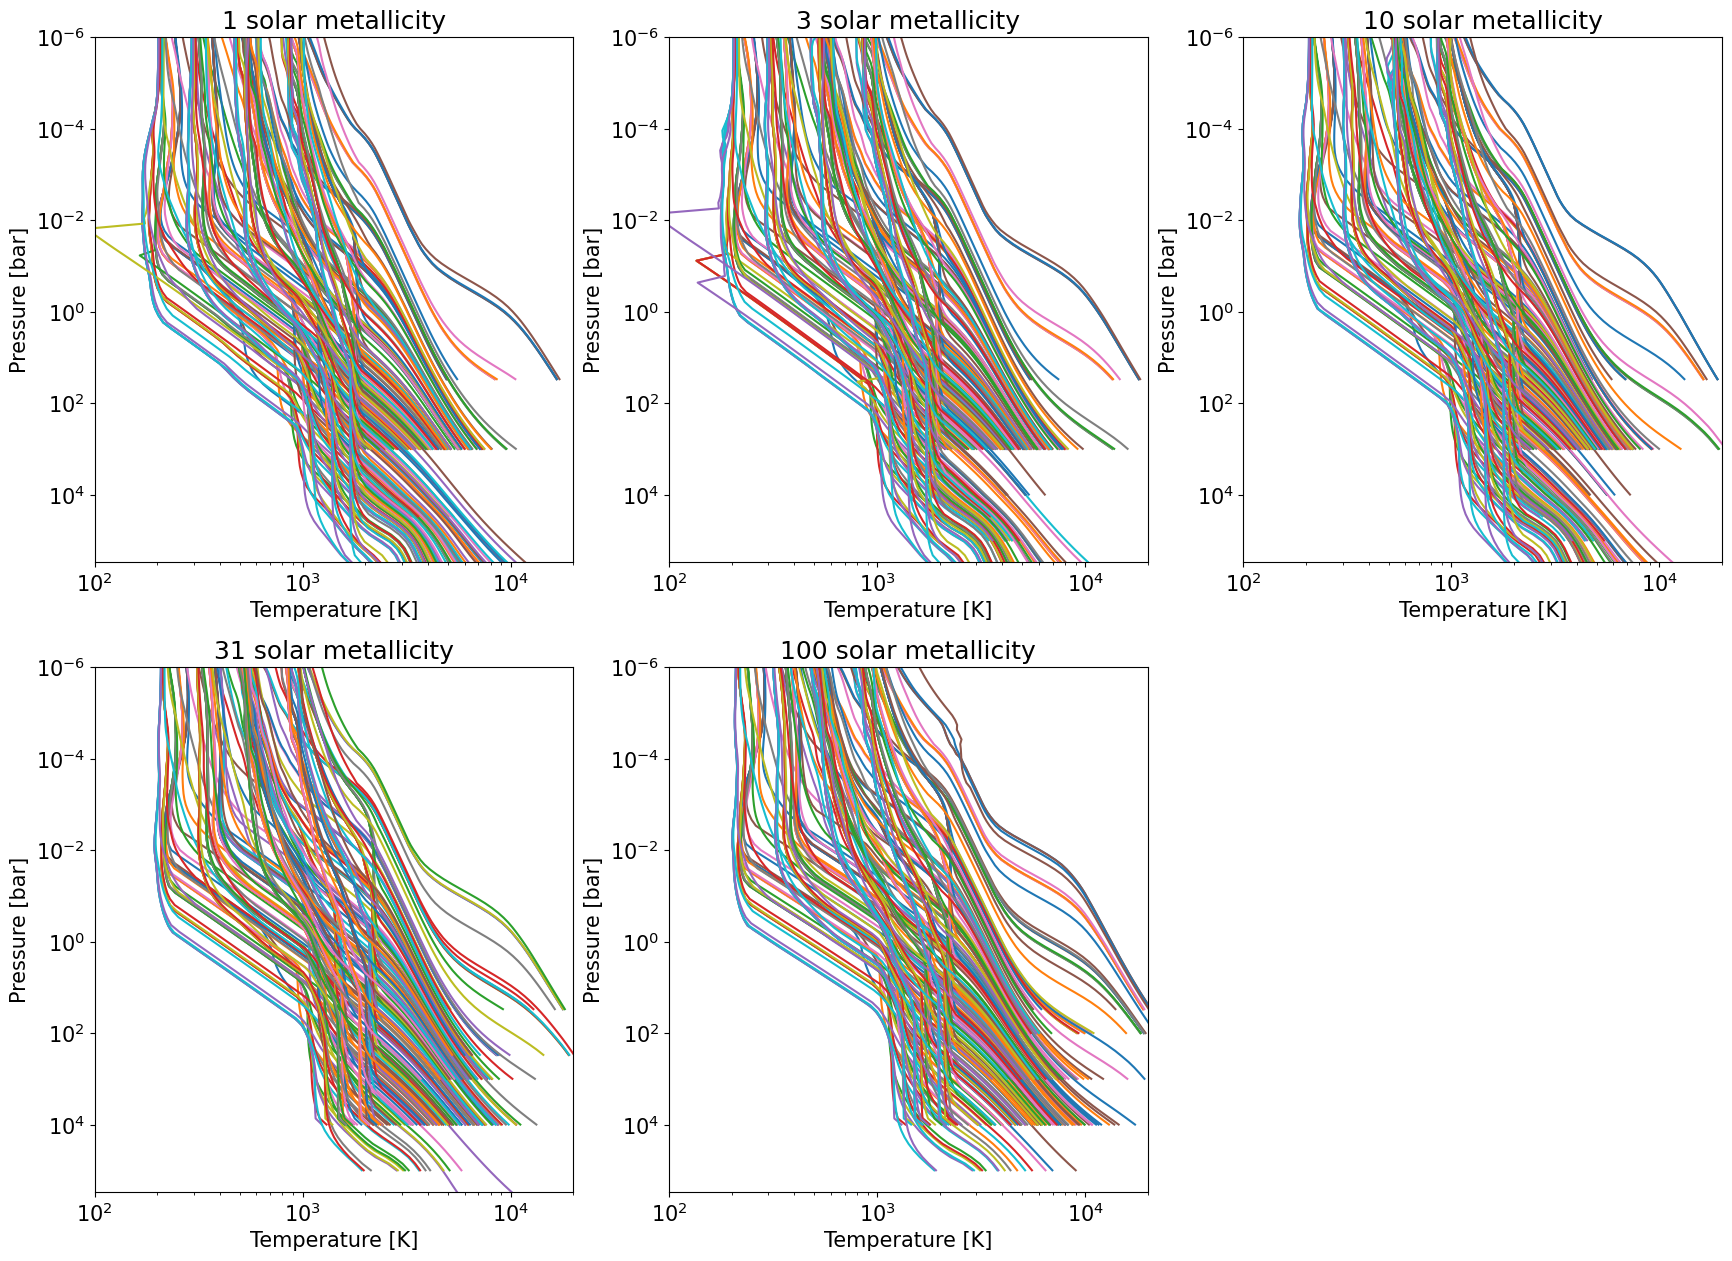

In [10]:
from matplotlib import pyplot as plt
plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = 21,15

# ---- Find missing grid ---
Zlist = ["1","3","10","31","100"]

fig = plt.figure()

#Zlist = ["1"]
for i in range(len(Zlist)):
    ax = plt.subplot(2,3,i+1)
    for Teq in range(6,10,1):
        for Tint in range(1,12,1):
            for grav in range(1,6,1):
                #n = n+1
                fname = "PT_Z"+Zlist[i]+"_Teq"+str(Teq).zfill(2)+"_Tin"+str(Tint).zfill(3)+"_g"+str(grav*100)+".dat"                
                if( os.path.exists(fname) ):
                    #print(fname)
                    data = np.loadtxt(fname,skiprows=4)
                    ax.plot(data[:,2],data[:,1])
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim([100,20000])
    ax.set_ylim([3e5,1e-6])           
    ax.set_xlabel('Temperature [K]')
    ax.set_ylabel('Pressure [bar]')
    ax.set_title(Zlist[i]+' solar metallicity')
                        
plt.savefig('Grid_gallery.pdf',dpi=144,bbox_inches='tight')


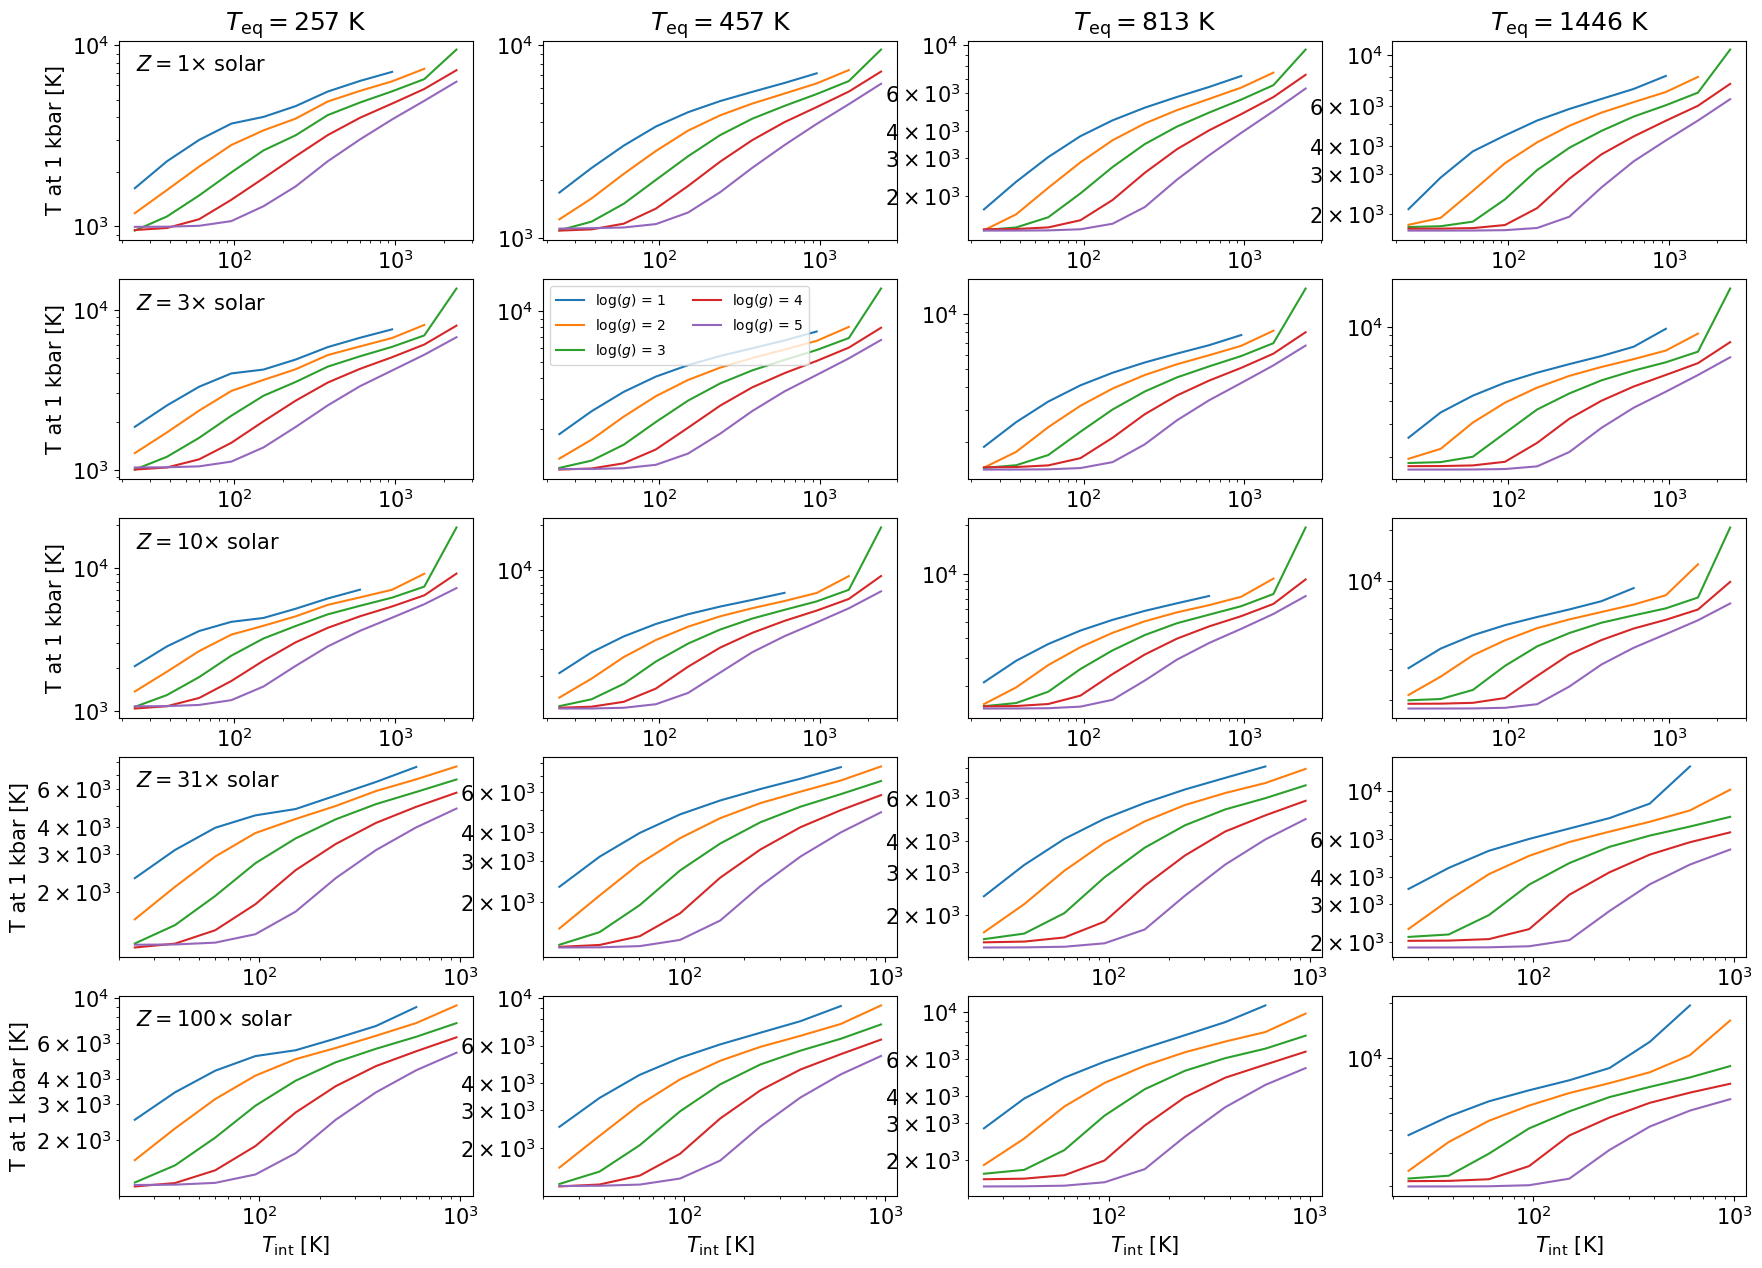

In [11]:
from matplotlib import pyplot as plt
plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = 21,15
from scipy.interpolate import interp1d

# ---- Find missing grid ---
Zlist = ["1","3","10","31","100"]
#Tint_arr = 24 * 10**((np.arange(1, 12, 1) - 1) / 5)
Teq_arr = ['257',  '457',  '813', '1446'] #taken from file
logg_arr = ['1', '2', '3', '4', '5']

fig = plt.figure()

#Zlist = ["1"]
for i in range(len(Zlist)):
    for j, Teq in enumerate(np.arange(6,10,1)):
        ax = plt.subplot(5,4,4*i + j + 1)
        for g, grav in enumerate(range(1,6,1)):
            Tint_arr = []
            T10_arr = []
            for Tint in range(1,12,1):
                fname = "PT_Z"+Zlist[i]+"_Teq"+str(Teq).zfill(2)+"_Tin"+str(Tint).zfill(3)+"_g"+str(grav*100)+".dat"                
                if(os.path.exists(fname)):
                    T_int_value = 24 * 10**((Tint-1)/5)
                    Tint_arr.append(T_int_value)
                    data = np.loadtxt(fname,skiprows=4)
                    T10_arr.append(10**interp1d(np.log10(data[:,1]), np.log10(data[:,2]), bounds_error=False, fill_value=np.nan)(3.))
            ax.plot(Tint_arr, T10_arr, label='log($g$) = ' + logg_arr[g])
        ax.set_xscale('log')
        ax.set_yscale('log')          
        if i == 4:
            ax.set_xlabel('$T_{\\rm int}$ [K]')
        if j == 0:
            ax.set_ylabel('T at 1 kbar [K]')
            ax.annotate('$Z = $' + Zlist[i] +'$\\times$ solar', xy=(0.05, 0.85), xycoords='axes fraction')
        if i == 0:
            ax.set_title('$T_{\\rm eq} = $' + Teq_arr[j] + ' K')

        if i == 1 and j == 1:
            ax.legend(ncols=2, fontsize=10)
                        
#plt.savefig('Grid_gallery.pdf',dpi=144,bbox_inches='tight')


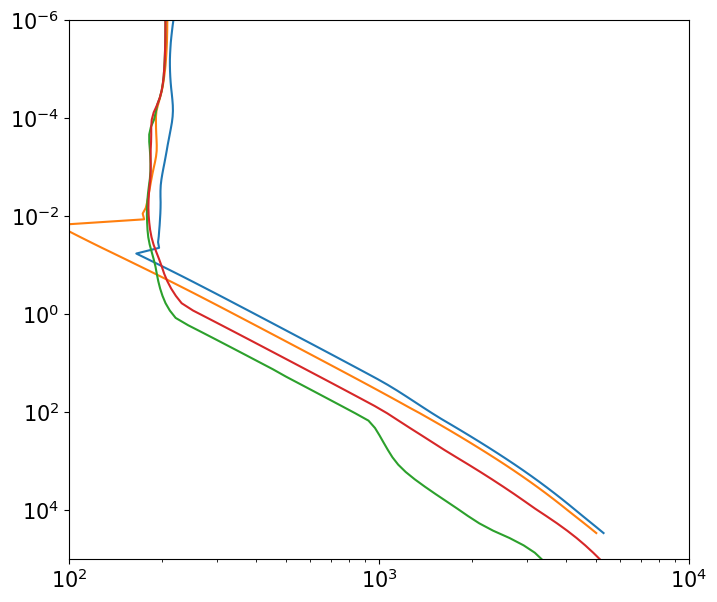

In [12]:
from matplotlib import pyplot as plt
plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = 8,7

# ---- Find missing grid ---
#Zlist = ["1","3","10","31","100"]
Zlist = ["1"]

fname_list = ["PT_Z1_Teq06_Tin005_g300.dat",
              #"PT_Z1_Teq06_Tin005_g500.dat",
              "PT_Z1_Teq06_Tin006_g400.dat",              
              "PT_Z3_Teq06_Tin004_g500.dat",
              "PT_Z3_Teq06_Tin006_g500.dat",
              #"PT_Z3_Teq06_Tin007_g500.dat",
              #"PT_Z31_Teq06_Tin007_g500.dat",
              #"PT_Z31_Teq06_Tin001_g500.dat"
             ]

fig = plt.figure()
ax = plt.subplot(111)
for i in range(len(fname_list)):
    fname = fname_list[i]
    if( os.path.exists(fname) ):
        data = np.loadtxt(fname,skiprows=4)
        ax.plot(data[:,2],data[:,1])
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim([100,10000])
    ax.set_ylim([1e5,1e-6])                    

In [13]:
data.shape

(91, 18)

In [14]:
import astropy.constants as c

density = data[:,1] * 1e5 * data[:,5] * 1e-3 / data[:,2] / c.R.value #SI units
entropy = 2.5 * c.R.value * np.log(data[:,2]) - c.R.value * np.log(density)
entropy_kb_baryon = entropy / (c.k_B.value * c.N_A.value * data[:,5])

(1000000.0, 1e-06)

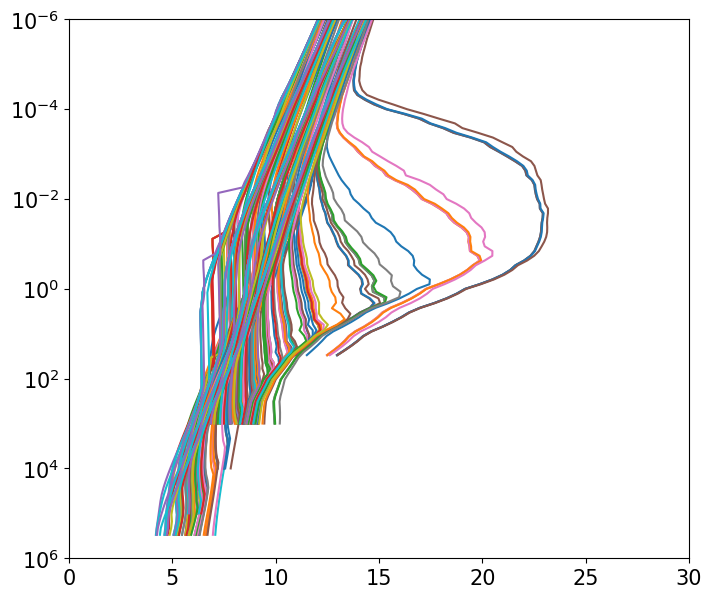

In [15]:
from matplotlib import pyplot as plt
plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = 8,7

# ---- Find missing grid ---
#Zlist = ["1","3","10","31","100"]
Zlist = ["3"]

fig = plt.figure()
ax = plt.subplot(111)

n = 0
n_err = 0
for i in range(len(Zlist)):
    for Teq in range(6,10,1):
        for Tint in range(1,12,1):
            for grav in range(1,6,1):
                n = n+1
                fname = "PT_Z"+Zlist[i]+"_Teq"+str(Teq).zfill(2)+"_Tin"+str(Tint).zfill(3)+"_g"+str(grav*100)+".dat"                
                if( os.path.exists(fname) ):
                    #print(fname)
                    data = np.loadtxt(fname,skiprows=4)
                    density = data[:,1] * 1e5 * data[:,5] * 1e-3 / data[:,2] / c.R.value #SI units
                    entropy = 2.5 * c.R.value * np.log(data[:,2]) - c.R.value * np.log(density)
                    entropy_kb_baryon = entropy / (c.k_B.value * c.N_A.value * data[:,5])
                    ax.semilogy(entropy_kb_baryon,data[:,1])
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlim([0,30])
ax.set_ylim([1e6,1e-6])                    